# Planet to planet low-thrust (with Alpha encoding)

In this tutorial we show the use of the {class}`pykep.trajopt.direct_pl2pl` to find a low-thrust trajectory connecting two moving planets. 

The decision vector for this class, compatible with pygmo {cite:p}`pagmo` UDPs (User Defined Problems), is:

$$
\mathbf x = [t_0, m_f, V_{sx}^\infty, V^\infty_{sy}, V^\infty_{sz}, V^\infty_{fx}, V^\infty_{fy}, V^\infty_{fz}, \alpha_{0}, \alpha_{1}, ..., u_{x0}, u_{y0}, u_{z0}, u_{x1}, u_{y1}, u_{z1}, ..., T_{tof}]
$$

containing the starting epoch $t_0$ as a MJD2000, the final mass $m_f$ as well as the starting and final $V^{\infty}$, throttles and the time-of-flight $T_{tof}$.

:::{note}
This notebook makes use of the commercial solver SNOPT 7 and to run needs a valid `snopt_7_c` library installed in the system. In case SNOPT7 is not available, you can still run the notebook using, for example `uda = pg.algorithm.nlopt("slsqp")` with minor modifications.

Basic imports:

In [1]:
import pykep as pk
import numpy as np
import time
import pygmo as pg
import pygmo_plugins_nonfree as ppnf
import time

from matplotlib import pyplot as plt

We start defining the problem data.

In [ ]:
# # Problem data

####
# ##  Test 1
mu = pk.MU_SUN
max_thrust = 0.6
isp = 3000
tof = 250.0
tof_lb = tof
t0_lb = 0
t0_ub = 0

posvel0 = [
    [34110913367.783306, -139910016918.87585, -14037825669.025244],
    [29090.9902134693, 10000.390168313803, 1003.3858682643288],
]
posvelf = [
    [-159018773159.22266, -18832495968.945133, 15781467087.350443],
    [2781.182556622003, -28898.40730995848, -483.4533989771214],
]

# Define initial and target
p1 = pk.planet(pk.udpla.keplerian(when=pk.epoch(0), posvel = posvel0, mu_central_body=mu))
p2 = pk.planet(pk.udpla.keplerian(when=pk.epoch(tof), posvel = posvelf, mu_central_body=mu))

# Initial state
ms = 1500.0
opt_mass = 1259.86
opt_thresh = 0.999
# opt_thresh = 2

# Number of segments
nseg = 8


# ####
# ## Testcase 2 (less easy, homotopy needed) [Earth-Mars with]
# mu = pk.MU_SUN
# max_thrust = 0.6
# isp = 3000
# tof = 550.0
# tof_lb = tof
# t0_lb = 0
# t0_ub = 0

# posvel0 = [
#     [-125036811000.422, -83670919168.87277, 2610252.8064399767],
#     [16081.829029183446, -24868.923007449284, 0.7758272135425942]
# ]
# posvelf = [
#     [-169327023332.1986, -161931354587.78766, 763967345.9733696],
#     [17656.297796509956, -15438.116653052988, -756.9165272457421]
# ]

# # Define initial and target
# p1 = pk.planet(pk.udpla.keplerian(when=pk.epoch(0), posvel = posvel0, mu_central_body=mu))
# p2 = pk.planet(pk.udpla.keplerian(when=pk.epoch(tof), posvel = posvelf, mu_central_body=mu))

# # Initial state
# ms = 1500.0
# opt_mass = 1237.68
# opt_thresh = 2

# # Number of segments
# nseg = 16



# ####
# ## Testcase 3 [Earth-Mars with longer time of flight and free initial and final conditions.
# mu = pk.MU_SUN
# max_thrust = 0.1
# isp = 3000
# tof = 1500.0
# tof_lb = 0.8 * tof
# t0_lb = 0
# t0_ub = 100.0

# posvel0 = [
#     [-125036811000.422, -83670919168.87277, 2610252.8064399767],
#     [16081.829029183446, -24868.923007449284, 0.7758272135425942]
# ]
# posvelf = [
#     [-169327023332.1986, -161931354587.78766, 763967345.9733696],
#     [17656.297796509956, -15438.116653052988, -756.9165272457421]
# ]

# # Define initial and target
# p1 = pk.planet(pk.udpla.keplerian(when=pk.epoch(0), posvel = posvel0, mu_central_body=mu))
# p2 = pk.planet(pk.udpla.keplerian(when=pk.epoch(tof), posvel = posvelf, mu_central_body=mu))

# # Initial state
# ms = 1500.0

# opt_mass = 1500
# opt_thresh = 0.9

# # # Number of segments
# # nseg = 8


SNOPT

In [3]:
snopt72 = "/Users/harry.holt/opt/libsnopt7_c.dylib"
uda = ppnf.snopt7(library=snopt72, minor_version=2, screen_output=False)
uda.set_integer_option("Major iterations limit", 2000)
uda.set_integer_option("Iterations limit", 20000)
uda.set_numeric_option("Major optimality tolerance", 1e-3)
uda.set_numeric_option("Major feasibility tolerance", 1e-11)

# Define Algorithm
algo = pg.algorithm(uda)

In [4]:
# Create a for Loop that will store results from 
# Nseg = 2 to Nseg = 24

# Storage
nseg_const_array = []
nseg_alpha_array = []
opt_const_array = []
opt_alpha_array = []
time_const_array = []
time_alpha_array = []

solve_const = True
solve_alpha = True

steps = 10

# For Loop
for nn in range(4,10+1):

        nseg = nn
        # print('\nNseg:',nseg)

        udp_lf = pk.trajopt.direct_pl2pl(
                pls=p1,
                plf=p2,
                ms=ms,
                mu=mu,
                max_thrust=max_thrust,
                isp=isp,
                t0_bounds=[t0_lb, t0_ub],
                tof_bounds=[tof_lb,tof],
                mf_bounds=[ms*0.5, ms],
                vinfs=0.,
                vinff=0.,
                nseg=nseg,
                cut=0.6,
                mass_scaling=ms,
                r_scaling=pk.AU,
                v_scaling=pk.EARTH_VELOCITY,
                with_gradient=False,
                high_fidelity=False
        )

        udp_alpha = pk.trajopt.direct_pl2pl_alpha(
                pls=p1,
                plf=p2,
                ms=ms,
                mu=mu,
                max_thrust=max_thrust,
                isp=isp,
                t0_bounds=[t0_lb, t0_ub],
                tof_bounds=[tof_lb,tof],
                mf_bounds=[ms*0.5, ms],
                vinfs=0.,
                vinff=0.,
                nseg=nseg,
                cut=0.6,
                mass_scaling=ms,
                r_scaling=pk.AU,
                v_scaling=pk.EARTH_VELOCITY,
                high_fidelity=False
        )

        if solve_const:

                # Without Alpha
                prob_lf = pg.problem(udp_lf)
                prob_lf.c_tol = 1e-6

                # With Alpha
                prob_alpha = pg.problem(udp_alpha)
                prob_alpha.c_tol = 1e-6

                # Solve in multi start

                # Without Alpha
                start_time = time.time()


                masses_lf = []
                xs_lf = []
                for i in range(steps):
                        try:
                                pop_lf = pg.population(prob_lf, 1)
                                pop_lf = algo.evolve(pop_lf)
                                if(prob_lf.feasibility_f(pop_lf.champion_f)):
                                        # print(".", end="")
                                        masses_lf.append(pop_lf.champion_x[1])
                                        xs_lf.append(pop_lf.champion_x)
                                        # break
                                # else:
                                #         print("x", end ="")
                        except:
                               print('Failed') 

                if len(masses_lf) > 0:
                        
                        nseg_const_array.append(nseg)
                        comp_time = time.time() - start_time

                        opt_const_array.append(np.max(masses_lf))
                        time_const_array.append(comp_time/steps)

                        if opt_const_array[-1] > opt_thresh* opt_mass: solve_const = False

                # else:
                #         solve_const = False

        if solve_alpha:

                # With Alpha
                start_time = time.time()

                masses_alpha = []
                xs_alpha = []
                # steps_failed = 0

                for i in range(steps):
                        try:

                                pop_alpha = pg.population(prob_alpha, 1)
                                
                                # Push back average spacing
                                x_tmp = pop_alpha.champion_x
                                x_tmp[8:8+nseg] = pk.direct2alpha([1/nseg]*nseg)[0]
                                pop_alpha.push_back(x_tmp)

                                # if i == 0: # Push back the constant result
                                # pop_alpha.push_back(x_tmp)
                                
                                pop_alpha = algo.evolve(pop_alpha)
                                if(prob_alpha.feasibility_f(pop_alpha.champion_f)):
                                        # print(".", end="")
                                        masses_alpha.append(pop_alpha.champion_x[1])
                                        xs_alpha.append(pop_alpha.champion_x)
                                        # break
                                # else:
                                        # print("x", end ="")
                        except:
                                print('Failed')


                if len(masses_alpha) > 0:
                        
                        nseg_alpha_array.append(nseg)

                        comp_time = time.time() - start_time

                        opt_alpha_array.append(np.max(masses_alpha))
                        time_alpha_array.append(comp_time/(steps))

                        if opt_alpha_array[-1] > opt_thresh * opt_mass: solve_alpha = False

                # else:
                #         solve_alpha = False
        
        if len(opt_const_array) > 0 and len(opt_alpha_array) > 0:
                print('Nseg:',nseg,'Const', solve_const,opt_const_array[-1], opt_const_array[-1]/opt_mass, time_const_array[-1],'s','Alpha', solve_alpha, opt_alpha_array[-1], opt_alpha_array[-1]/opt_mass, time_alpha_array[-1],'s')
        
        if solve_const == False and solve_alpha == False: break

Nseg: 4 Const True 1255.8966926409835 0.9968541684321938 0.2196129083633423 s Alpha True 1267.3258026109656 1.005925898600611 0.303765606880188 s
Nseg: 5 Const True 1258.0076828678393 0.998529743676154 0.24304399490356446 s Alpha True 1268.1925588194333 1.0066138767953847 0.31071019172668457 s
Nseg: 6 Const True 1258.3902097289897 0.9988333701593747 0.29224867820739747 s Alpha True 1267.6960295136325 1.0062197621272464 0.47937450408935545 s
Nseg: 7 Const True 1261.5905603724077 1.001373613236715 0.29396653175354004 s Alpha True 1268.056167228595 1.006505617472255 0.712456488609314 s
Nseg: 8 Const True 1259.9655327275034 1.0000837654402104 0.3198704719543457 s Alpha True 1264.8587248503736 1.0039676827983852 0.7441884040832519 s
Nseg: 9 Const True 1259.8308798260418 0.999976886182625 0.46555290222167967 s Alpha True 1267.8788971553236 1.0063649113038937 0.5990778207778931 s
Nseg: 10 Const True 1259.82686817065 0.9999737019753385 0.4018178701400757 s Alpha True 1265.3265561075982 1.00433

Now plot the results

/var/folders/0h/f0gztpmj7nn5c_kq4kb80ph821r1zz/T/ipykernel_84459/3146844608.py:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  ax2.plot(nseg_alpha_array, time_alpha_array, 'r--',color='C1', label='Time Alpha')


<Figure size 800x500 with 0 Axes>

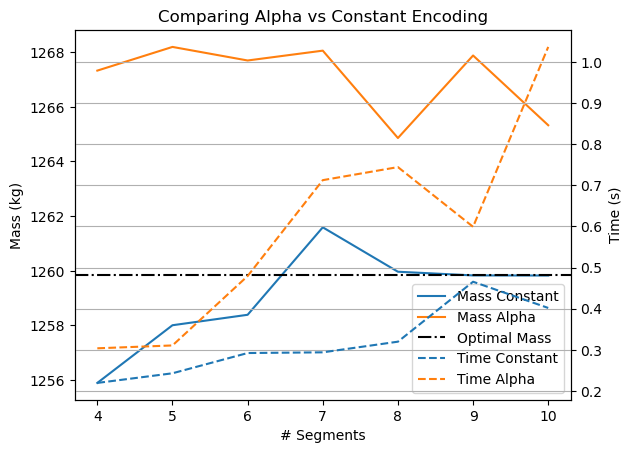

In [5]:
plt.figure(figsize=(8, 5))
fig, ax1 = plt.subplots()

# Plot opt arrays on the left y-axis
ax1.plot(nseg_const_array, opt_const_array, '-', color='C0', label='Mass Constant')
ax1.plot(nseg_alpha_array, opt_alpha_array, '-', color='C1', label='Mass Alpha')
ax1.axhline(y=opt_mass, color='k', linestyle='-.', label='Optimal Mass')
if opt_thresh<1:
    ax1.axhline(y=opt_thresh*opt_mass, color='k', linestyle=':', label=f'{opt_thresh*100}% Threshold')
ax1.set_xlabel('# Segments')
ax1.set_ylabel('Mass (kg)', color='black')
ax1.tick_params(axis='y', labelcolor='black')
# ax1.set_ylim([opt_const_array[0]*opt_thresh,opt_mass*(1+1-opt_thresh)])

# Create a second y-axis for time arrays
ax2 = ax1.twinx()
ax2.plot(nseg_const_array, time_const_array, '--', color='C0', label='Time Constant')
ax2.plot(nseg_alpha_array, time_alpha_array, 'r--',color='C1', label='Time Alpha')
ax2.set_ylabel('Time (s)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Combine legends from both axes
ax1_handles, ax1_labels = ax1.get_legend_handles_labels()
ax2_handles, ax2_labels = ax2.get_legend_handles_labels()
ax1.legend(ax1_handles + ax2_handles, ax1_labels + ax2_labels, loc='best')

plt.title('Comparing Alpha vs Constant Encoding')
plt.grid(True)
plt.show()